# Assignment 1: From Dirty Data to Predictive Models

## Titanic Survival Prediction

**Task:** Predict whether a Titanic passenger survived (`Survived` ∈ {0, 1}).

This notebook implements an end-to-end supervised learning workflow:

1. Data cleaning
2. Feature engineering
3. Model training (Naive Bayes and Linear Regression)
4. Model evaluation


## 0. Setup

Import the libraries used below and fix the constants that make the work reproducible.

The modeling dataset is `train.csv`, the only Kaggle file that contains the `Survived` label. A train/test split is built from it so the held-out portion has known labels for accuracy and confusion-matrix evaluation. Kaggle's `test.csv` has no labels and is not used; `gender_submission.csv` is not required.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import KBinsDiscretizer, OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.20
THRESHOLD = 0.5

sns.set_theme(style="whitegrid")

### 0.1 Locate the data

Expect `train.csv` in the notebook working directory (upload it to the Colab Files panel if needed).


In [2]:
TRAIN_PATH = Path("train.csv")
assert TRAIN_PATH.exists(), "train.csv not found. Upload it to the Colab Files panel."

print(f"Using labeled dataset: {TRAIN_PATH}")


Using labeled dataset: train.csv


# 1. Data Loading & Initial Exploration

Load the labeled Titanic data and establish its structure, target distribution, data types, and missing-data profile. These observations drive the cleaning decisions that follow.


In [3]:
df = pd.read_csv(TRAIN_PATH)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [6]:
df.describe(include="object").T

,count,unique,top,freq
Name,891,891,"Braund, Mr. Owen Harris",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,B96 B98,4
Embarked,889,3,S,644


In [7]:
missing_summary = (
    df.isna()
      .sum()
      .rename("missing_count")
      .to_frame()
      .assign(missing_pct=lambda x: (x["missing_count"] / len(df) * 100).round(2))
      .query("missing_count > 0")
      .sort_values("missing_count", ascending=False)
)

missing_summary

,missing_count,missing_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


**Interpretation.** Three columns contain missing values: `Cabin` (687, 77.10%), `Age` (177, 19.87%) and `Embarked` (2, 0.22%). The three magnitudes call for three different treatments, so no single blanket rule (drop all NaNs, or fill all NaNs) is appropriate.

In [8]:
target_summary = (
    df["Survived"]
      .value_counts()
      .rename_axis("Survived")
      .to_frame("count")
      .assign(percentage=lambda x: (x["count"] / len(df) * 100).round(2))
      .sort_index()
)

target_summary

,count,percentage
Survived,,
0,549,61.62
1,342,38.38


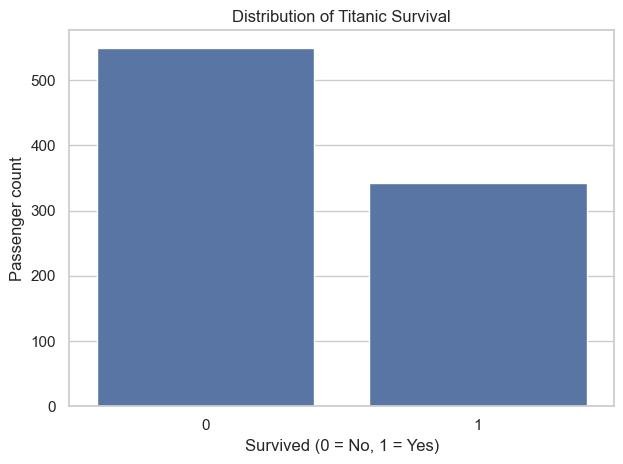

In [9]:
ax = sns.countplot(data=df, x="Survived")
ax.set_title("Distribution of Titanic Survival")
ax.set_xlabel("Survived (0 = No, 1 = Yes)")
ax.set_ylabel("Passenger count")
plt.tight_layout()
plt.show()

**Interpretation.** 549 passengers did not survive (61.62%) and 342 did (38.38%). The classes are moderately imbalanced but not severely so. This justifies a **stratified** train/test split later, so both partitions keep roughly the same survival rate. A trivial "always predict 0" classifier would already score about 61.6% accuracy, which is the baseline any model must beat.

## 2. Data Cleaning

Cleaning is organized into three stages:

1. **Audit** — look for duplicates, inconsistent categorical text, and invalid numeric values. Report honestly what is (and is not) found.
2. **Deterministic cleaning** — fixes that need no learned statistics (text normalization, the `CabinKnown` flag). These are safe to apply before splitting.
3. **Statistical imputation** — fixes that learn a statistic from data (median, most-frequent). These are fitted on the **training split only** to prevent data leakage.


In [10]:
print(f"Exact duplicate rows: {df.duplicated().sum()}")

Exact duplicate rows: 0


In [11]:
categorical_checks = {
    "Sex": sorted(df["Sex"].dropna().str.strip().str.lower().unique().tolist()),
    "Embarked": sorted(df["Embarked"].dropna().str.strip().str.upper().unique().tolist()),
}

categorical_checks

{'Sex': ['female', 'male'], 'Embarked': ['C', 'Q', 'S']}

In [12]:
numeric_quality_checks = {
    "Age_below_zero": int((df["Age"].dropna() < 0).sum()),
    "Fare_below_zero": int((df["Fare"].dropna() < 0).sum()),
    "SibSp_below_zero": int((df["SibSp"].dropna() < 0).sum()),
    "Parch_below_zero": int((df["Parch"].dropna() < 0).sum()),
    "invalid_Pclass": int((~df["Pclass"].dropna().isin([1, 2, 3])).sum()),
    "invalid_Survived": int((~df["Survived"].dropna().isin([0, 1])).sum()),
}

pd.Series(numeric_quality_checks, name="invalid_count").to_frame()

,invalid_count
Age_below_zero,0
Fare_below_zero,0
SibSp_below_zero,0
Parch_below_zero,0
invalid_Pclass,0
invalid_Survived,0


In [13]:
df.loc[df["Fare"] == 0].groupby("Pclass").size().rename("zero_fare_count").to_frame()

,zero_fare_count
Pclass,
1,5
2,6
3,4


**Audit findings.**

- **Duplicates:** none, so no rows are removed.
- **Categorical domains:** `Sex` ∈ {female, male} and `Embarked` ∈ {C, Q, S}. No typos or rogue categories exist. Normalization of whitespace/case is still applied defensively so that later encoders cannot split one category into two.
- **Numeric validity:** every check returns 0. There is **no noisy or invalid numeric data to correct**, and none is invented.
- **Zero fares:** 15 passengers (5 first-, 6 second-, 4 third-class) have `Fare == 0`. A zero is not impossible (it may reflect complimentary or unrecorded tickets) and cannot be verified from the data, so these values are **left unchanged**. Fare's skew is addressed by log-transformation in feature engineering.


### 2.1 Deterministic cleaning

`Sex`, `Embarked` and `Cabin` are trimmed and case-normalized. Missing values are preserved at this point; nothing is filled yet.

In [14]:
clean = df.copy()

clean["Sex"] = clean["Sex"].str.strip().str.lower()
clean["Embarked"] = clean["Embarked"].str.strip().str.upper()
clean["Cabin"] = clean["Cabin"].str.strip()

clean[["Sex", "Embarked", "Cabin"]].head()

,Sex,Embarked,Cabin
0,male,S,NaN
1,female,C,C85
2,female,S,NaN
3,female,S,C123
4,male,S,NaN


### 2.2 `CabinKnown` flag

`Cabin` is missing for 77.10% of passengers, so reconstructing cabin identifiers would mean inventing most of them. Instead, whether a cabin was **recorded** is kept as a binary feature. It is derived from the row itself and uses no statistics from other rows or from the target, so it is safe to compute before the split.

In [15]:
clean["CabinKnown"] = clean["Cabin"].notna().astype(int)

clean["CabinKnown"].value_counts().rename_axis("CabinKnown").to_frame("count").sort_index()

,count
CabinKnown,
0,687
1,204


## 3. Train/Test Split

The split is performed **before** any statistic is learned. It is stratified on `Survived` so that both partitions retain the original ~38% survival rate. This single split is reused unchanged by every model below.


In [16]:
X = clean.drop(columns="Survived")
y = clean["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

pd.DataFrame(
    {
        "rows": [len(y_train), len(y_test)],
        "survival_rate_pct": [round(y_train.mean() * 100, 2), round(y_test.mean() * 100, 2)],
    },
    index=["train", "test"],
)

,rows,survival_rate_pct
train,712,38.34
test,179,38.55


**Interpretation.** The split has 712 training and 179 test rows with survival rates of 38.34% and 38.55%, so stratification preserved the class balance.

Missing values are inspected again within each partition, and the `CabinKnown` signal is examined on the **training** partition only.

In [17]:
imputation_columns = ["Age", "Embarked"]

pd.DataFrame(
    {
        "train_missing": X_train[imputation_columns].isna().sum(),
        "test_missing": X_test[imputation_columns].isna().sum(),
    }
)

,train_missing,test_missing
Age,137,40
Embarked,2,0


In [18]:
(
    pd.concat([X_train["CabinKnown"], y_train], axis=1)
      .groupby("CabinKnown")["Survived"]
      .agg(passengers="size", survival_rate="mean")
      .round(3)
)

,passengers,survival_rate
CabinKnown,,
0,552,0.292
1,160,0.700


**Interpretation.** Missing `Age` appears in 137 training and 40 test rows; missing `Embarked` appears in 2 training rows and none in the test rows. On the training partition, passengers with a recorded cabin survived at 70.0% versus 29.2% for those without, so the cabin-availability flag carries real signal and is worth retaining.

## 4. Leakage-Safe Imputation

| Column | Strategy | Rationale |
|---|---|---|
| `Age` | Median of the training split | Retains ~20% of passengers that dropping would discard. The median is robust to the right-skewed age distribution and to outliers. |
| `Embarked` | Most frequent category of the training split | Only 2 missing values in a categorical variable; the mode is the least intrusive fill. |

Each imputer is **fitted on `X_train` only**, then used to **transform** both partitions. The test partition therefore never influences the statistics.

In [19]:
age_imputer = SimpleImputer(strategy="median").fit(X_train[["Age"]])
embarked_imputer = SimpleImputer(strategy="most_frequent").fit(X_train[["Embarked"]])

pd.Series(
    {
        "Age median (training split)": age_imputer.statistics_[0],
        "Embarked mode (training split)": embarked_imputer.statistics_[0],
    },
    name="learned_value",
).to_frame()

,learned_value
Age median (training split),28.5
Embarked mode (training split),S


In [20]:
def apply_imputers(features):
    imputed = features.copy()
    imputed["Age"] = age_imputer.transform(imputed[["Age"]]).ravel()
    imputed["Embarked"] = embarked_imputer.transform(imputed[["Embarked"]]).ravel()
    return imputed


X_train_clean = apply_imputers(X_train)
X_test_clean = apply_imputers(X_test)

### 4.1 Verification

The following checks confirm that the imputed columns are complete in both partitions, that no rows were dropped or reordered, and that the target did not leak into the features.

In [21]:
checked_columns = ["Age", "Embarked", "CabinKnown"]

assert X_train_clean[checked_columns].notna().all().all()
assert X_test_clean[checked_columns].notna().all().all()
assert "Survived" not in X_train_clean.columns and "Survived" not in X_test_clean.columns
assert X_train_clean.index.equals(X_train.index) and X_test_clean.index.equals(X_test.index)
assert len(X_train_clean) + len(X_test_clean) == len(df)

pd.concat(
    {
        "train": pd.DataFrame(
            {"before": X_train[imputation_columns].isna().sum(),
             "after": X_train_clean[imputation_columns].isna().sum()}
        ),
        "test": pd.DataFrame(
            {"before": X_test[imputation_columns].isna().sum(),
             "after": X_test_clean[imputation_columns].isna().sum()}
        ),
    },
    axis=1,
)

train         test      
         before after before after
Age         137     0     40     0
Embarked      2     0      0     0

### 4.2 Before/after evidence

Individual records, and the effect on the `Age` distribution of the training partition.

In [22]:
(
    pd.DataFrame({"Age_before": X_train["Age"], "Age_after": X_train_clean["Age"]})
      .loc[X_train["Age"].isna()]
      .head(5)
)

,Age_before,Age_after
692,NaN,28.5
481,NaN,28.5
527,NaN,28.5
557,NaN,28.5
828,NaN,28.5


In [23]:
embarked_before = pd.concat([X_train, X_test])["Embarked"]
embarked_after = pd.concat([X_train_clean, X_test_clean])["Embarked"]

(
    pd.DataFrame({"Embarked_before": embarked_before, "Embarked_after": embarked_after})
      .loc[embarked_before.isna()]
      .assign(split=lambda t: ["train" if i in X_train.index else "test" for i in t.index])
)

,Embarked_before,Embarked_after,split
829,NaN,S,train
61,NaN,S,train


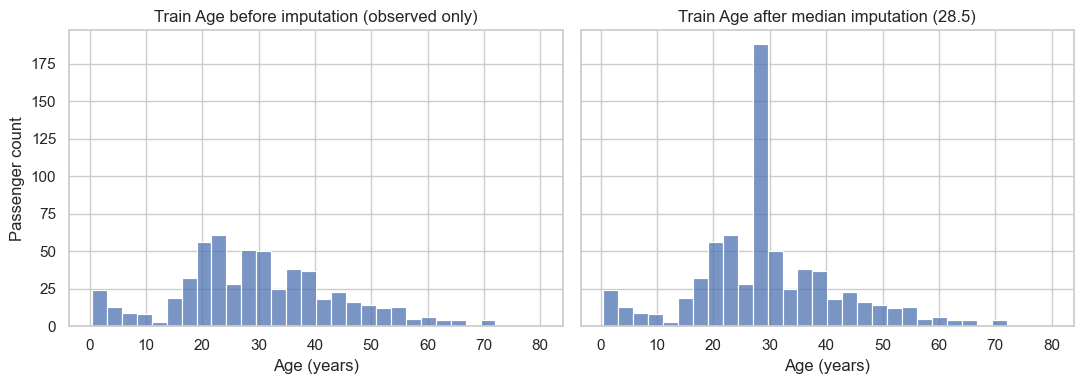

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

sns.histplot(X_train["Age"].dropna(), bins=30, ax=axes[0])
axes[0].set_title("Train Age before imputation (observed only)")

sns.histplot(X_train_clean["Age"], bins=30, ax=axes[1])
axes[1].set_title(f"Train Age after median imputation ({age_imputer.statistics_[0]:.1f})")

for ax in axes:
    ax.set_xlabel("Age (years)")
axes[0].set_ylabel("Passenger count")

plt.tight_layout()
plt.show()

In [25]:
pd.DataFrame(
    {
        "before": X_train["Age"].describe(),
        "after": X_train_clean["Age"].describe(),
    }
).round(2)

,before,after
count,575.00,712.00
mean,29.81,29.56
std,14.49,13.03
min,0.42,0.42
25%,21.00,22.00
50%,28.50,28.50
75%,39.00,36.00
max,80.00,80.00


**Interpretation.** All gaps in `Age` and `Embarked` are filled in both partitions, and row counts are unchanged (712 + 179 = 891). The learned fill values are an Age of 28.5 years and port `S` (Southampton, the most common port). The histogram shows the main side effect of median imputation: a spike at the median and a narrower standard deviation than the observed ages. This is an accepted trade-off for keeping 137 + 40 passengers.


## 5. Cleaning Decisions

| Variable | Problem found | Decision | Rationale |
|---|---|---|---|
| `Age` | 19.87% missing | Median imputation, fitted on the training split only | Keeps ~1 in 5 passengers; median is robust to skew; no test leakage |
| `Embarked` | 0.22% missing (2 rows) | Most-frequent imputation, fitted on the training split only | Negligible missingness in a categorical variable |
| `Cabin` | 77.10% missing | Not imputed; `CabinKnown` flag created | Too sparse to reconstruct without inventing values; availability itself is informative |
| `Sex`, `Embarked`, `Cabin` | Possible whitespace/case inconsistencies | Trimmed; `Sex` lower-cased, `Embarked` upper-cased | Prevents one category being split into several by encoders |
| Numeric/target fields | No negative or out-of-domain values | No correction | Audit found no violations |
| `Fare` | 15 zero values | Left unchanged | Zero is not demonstrably invalid; skew handled in feature engineering |
| Duplicates | None found | No rows removed | Nothing to remove |
| `Survived` | Complete and valid | Kept as target only | Never used as an input feature |


In [26]:
X_train_clean.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,CabinKnown
692,693,3,"Lam, Mr. Ali",male,28.5,0,0,1601,56.4958,NaN,S,0
481,482,2,"Frost, Mr. Anthony Wood ""Archie""",male,28.5,0,0,239854,0.0000,NaN,S,0
527,528,1,"Farthing, Mr. John",male,28.5,0,0,PC 17483,221.7792,C95,S,1
855,856,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S,0
801,802,2,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",female,31.0,1,1,C.A. 31921,26.2500,NaN,S,0


# 6. Feature Engineering

Convert the cleaned frames into **numeric model matrices**. Three kinds of work are involved:

1. **Constructing features** from raw columns (`Title`, `FamilySize`, `IsAlone`, `Age_missing`, `LogFare`).
2. **Transforming** continuous variables (log-scaling, standardization, binning).
3. **Encoding** categorical variables (one-hot).

Row-wise features use only the passenger's own record, so they can be built before anything is fitted. Anything that **learns a parameter** (scaler mean/std, one-hot category list, fare-quantile edges) is fitted on the training partition only and then applied to the test partition.

The two model families have different needs, so the same split is represented in **two views**:

| View | Used by | Representation |
|---|---|---|
| **Linear view** | LinearRegression, Ridge, LASSO | Standardized continuous features + one-hot dummies with an explicit reference level |
| **Naive Bayes view** | BernoulliNB | Binary features only (continuous variables binned, categoricals one-hot) so that Laplace smoothing (`alpha`) acts on meaningful counts |


## 6.1 Columns that are not used as predictors

| Column | Decision | Reason |
|---|---|---|
| `PassengerId` | Excluded | Row identifier with no predictive meaning |
| `Name` | Excluded as raw text; `Title` is extracted | Every name is unique; the title carries the usable social/age/sex information |
| `Ticket` | Excluded | High-cardinality, identifier-like; shared-ticket group effects are approximated by `FamilySize` |
| `Cabin` (raw string) | Excluded; `CabinKnown` (created above) is used | Too sparse to encode; availability is the usable signal |
| `SibSp`, `Parch` | Replaced by `FamilySize` and `IsAlone` | `FamilySize = SibSp + Parch + 1` is an exact linear combination; keeping all three would make the linear design matrix rank-deficient |
| `Fare` | Replaced by `LogFare` | Strong right skew (see 6.3) |
| `Survived` | Target only | Already separated into `y_train` / `y_test` |

In [27]:
identifier_profile = X_train_clean[["PassengerId", "Name", "Ticket", "Cabin"]].nunique()
identifier_profile.rename("distinct_values").to_frame().assign(rows=len(X_train_clean))

,distinct_values,rows
PassengerId,712,712
Name,712,712
Ticket,571,712
Cabin,127,712


**Interpretation.** `PassengerId` and `Name` have one distinct value per row, so they cannot generalize to unseen passengers. `Ticket` has 571 distinct values across 712 rows, and `Cabin` 127 across its 160 recorded values, so both are close to identifiers. Using them would let a flexible model memorize individuals instead of learning patterns, so they are excluded.

## 6.2 Constructed features

| Feature | Definition | Interpretation | Leakage |
|---|---|---|---|
| `Title` | Text between the comma and the period in `Name`; `Mlle`/`Ms` → `Miss`, `Mme` → `Mrs`; anything other than `Mr`, `Miss`, `Mrs`, `Master` → `Rare` | Combines sex, marital status and age (`Master` = young boy) | None. The mapping is fixed in advance, not learned |
| `FamilySize` | `SibSp + Parch + 1` | Size of the travelling family group | None |
| `IsAlone` | `FamilySize == 1` | Travelling alone vs. with family | None |
| `Age_missing` | 1 if `Age` was missing **before** imputation | Preserves the information that median imputation would otherwise erase | None. Derived from the passenger's own raw record |
| `LogFare` | `log1p(Fare)` | Compresses the heavy right tail | None |
| `AgeGroup` (NB view only) | Fixed bins: child ≤ 12, teen ≤ 18, young adult ≤ 35, adult ≤ 60, senior > 60 | Interpretable life-stage groups for BernoulliNB | None. Domain-defined edges, not fitted |

`Pclass` is treated as a **categorical** variable (class 1/2/3 is an ordered label, not a quantity), so each class gets its own effect.

In [28]:
CORE_TITLES = ["Mr", "Miss", "Mrs", "Master"]
TITLE_ALIASES = {"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"}
AGE_BIN_EDGES = [0, 12, 18, 35, 60, np.inf]
AGE_BIN_LABELS = ["child", "teen", "young_adult", "adult", "senior"]


def extract_title(names):
    # Fixed mapping (not learned from data); unseen titles fall back to "Rare".
    titles = names.str.extract(r",\s*([^.]+)\.", expand=False).str.strip().replace(TITLE_ALIASES)
    return titles.where(titles.isin(CORE_TITLES), "Rare")


def engineer_features(imputed, raw):
    # `raw` is the pre-imputation frame; it is needed only to recover Age_missing.
    out = imputed.copy()
    out["Age_missing"] = raw["Age"].isna().astype(int)
    out["Title"] = extract_title(out["Name"])
    out["FamilySize"] = out["SibSp"] + out["Parch"] + 1
    out["IsAlone"] = (out["FamilySize"] == 1).astype(int)
    out["LogFare"] = np.log1p(out["Fare"])
    out["AgeGroup"] = pd.cut(out["Age"], bins=AGE_BIN_EDGES, labels=AGE_BIN_LABELS).astype(str)
    out["Pclass"] = out["Pclass"].astype(str)  # categorical, not a quantity
    return out


train_features = engineer_features(X_train_clean, X_train)
test_features = engineer_features(X_test_clean, X_test)

train_features[["Name", "Title", "SibSp", "Parch", "FamilySize", "IsAlone", "Age", "Age_missing", "AgeGroup", "Fare", "LogFare"]].head()

,Name,Title,SibSp,Parch,FamilySize,IsAlone,Age,Age_missing,AgeGroup,Fare,LogFare
692,"Lam, Mr. Ali",Mr,0,0,1,1,28.5,1,young_adult,56.4958,4.051712
481,"Frost, Mr. Anthony Wood ""Archie""",Mr,0,0,1,1,28.5,1,young_adult,0.0000,0.000000
527,"Farthing, Mr. John",Mr,0,0,1,1,28.5,1,young_adult,221.7792,5.406181
855,"Aks, Mrs. Sam (Leah Rosen)",Mrs,0,1,2,0,18.0,0,teen,9.3500,2.336987
801,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",Mrs,1,1,3,0,31.0,0,young_adult,26.2500,3.305054


Each constructed feature is checked against the target on the **training partition only** (the test partition is never inspected for modeling decisions).

In [29]:
train_eval = train_features.assign(Survived=y_train)

title_summary = (
    train_eval.groupby("Title")["Survived"]
      .agg(passengers="size", survival_rate="mean")
      .sort_values("survival_rate", ascending=False)
      .round(3)
)
title_summary

,passengers,survival_rate
Title,,
Mrs,107,0.785
Miss,144,0.708
Master,31,0.548
Rare,18,0.389
Mr,412,0.153


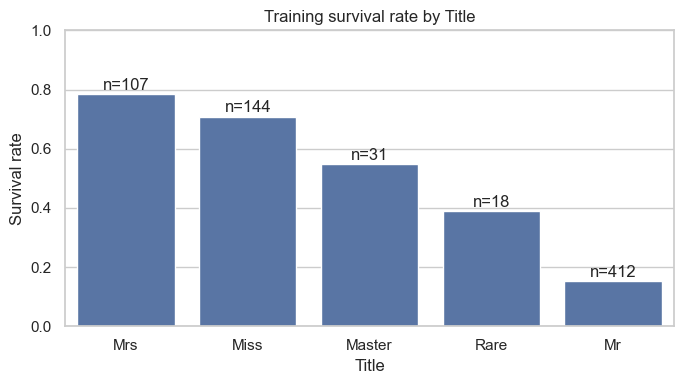

In [30]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=title_summary.reset_index(), x="Title", y="survival_rate", order=title_summary.index, ax=ax)
for position, (_, row) in enumerate(title_summary.iterrows()):
    ax.text(position, row["survival_rate"] + 0.015, f"n={int(row['passengers'])}", ha="center")
ax.set_title("Training survival rate by Title")
ax.set_xlabel("Title")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [31]:
pd.concat(
    {
        flag: train_eval.groupby(flag)["Survived"].agg(passengers="size", survival_rate="mean").round(3)
        for flag in ["Age_missing", "IsAlone"]
    }
)

passengers  survival_rate
            Age_missing                           
Age_missing 0                   575          0.405
            1                   137          0.292
IsAlone     0                   278          0.514
            1                   434          0.300

**Interpretation (training partition).**

- **`Title`** separates passengers more finely than `Sex` alone: `Mrs` (78.5%) and `Miss` (70.8%) survived far more often than `Mr` (15.3%), while `Master` (young boys, 54.8%) sit in between, so the title adds age information that `Sex` cannot. `Rare` (18 passengers, 38.9%) is small and heterogeneous, which justifies pooling those titles into one level.
- **`Age_missing`**: passengers with a missing age survived at 29.2% (137 passengers) versus 40.5% (575) for those with a recorded age. The difference suggests that missingness is informative, so the flag preserves a signal that median imputation would otherwise erase. This is an association, not a causal claim.
- **`IsAlone`**: passengers travelling alone survived at 30.0% (434) versus 51.4% (278) for those with family aboard, so the family-based features carry signal.

## 6.3 Log-scaling `Fare`

`Fare` has a long right tail (a few very expensive tickets). Heavily skewed inputs let a handful of extreme values dominate a linear fit. `log1p` compresses the tail while remaining defined at zero, which matters because 15 passengers have `Fare == 0`.


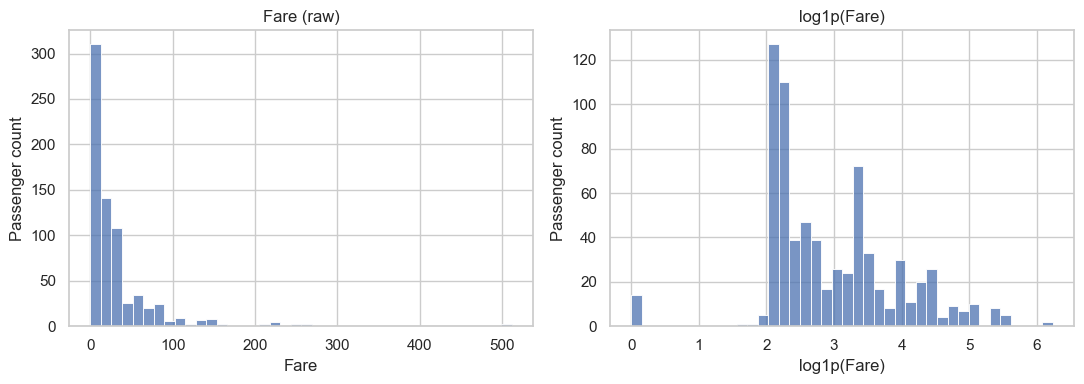

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(train_features["Fare"], bins=40, ax=axes[0])
axes[0].set_title("Fare (raw)")

sns.histplot(train_features["LogFare"], bins=40, ax=axes[1])
axes[1].set_title("log1p(Fare)")

for ax in axes:
    ax.set_ylabel("Passenger count")
axes[0].set_xlabel("Fare")
axes[1].set_xlabel("log1p(Fare)")

plt.tight_layout()
plt.show()

In [33]:
train_features[["Fare", "LogFare"]].skew().round(2).rename("skewness").to_frame()

,skewness
Fare,4.65
LogFare,0.31


**Interpretation.** The raw fare distribution is extremely right-skewed (skewness ≈ 4.65), with most passengers clustered at low fares and a few above 200. After `log1p` the skewness drops to ≈ 0.31 and the bulk of the distribution is far less stretched; the zero-fare passengers appear as a separate small cluster at 0.


## 6.4 Linear view: standardization and one-hot encoding

| Column group | Treatment | Why |
|---|---|---|
| `Age`, `LogFare`, `FamilySize` | `StandardScaler` (mean 0, std 1), **fitted on train** | Puts features on a common scale so coefficients are comparable and Ridge/LASSO penalize them fairly |
| `Pclass`, `Sex`, `Embarked`, `Title` | One-hot with an explicit **reference level** dropped: class 1, `female`, port `S`, title `Mr` | A full set of dummies plus an intercept is perfectly collinear (the "dummy-variable trap"). Dropping one level removes it and makes coefficients readable as "relative to the reference" |
| `IsAlone`, `CabinKnown`, `Age_missing` | Passed through (already 0/1) | No transformation needed |
| Everything else (`Name`, `Ticket`, `Cabin`, `PassengerId`, `SibSp`, `Parch`, `Fare`, `AgeGroup`) | Dropped by the `ColumnTransformer` | See 6.1 |

`handle_unknown="ignore"` makes the encoder robust to a category appearing only in the test partition.

In [34]:
NUMERIC_COLUMNS = ["Age", "LogFare", "FamilySize"]
CATEGORICAL_COLUMNS = ["Pclass", "Sex", "Embarked", "Title"]
BINARY_COLUMNS = ["IsAlone", "CabinKnown", "Age_missing"]
REFERENCE_LEVELS = ["1", "female", "S", "Mr"]  # one per categorical column, in order

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), NUMERIC_COLUMNS),
        (
            "onehot",
            OneHotEncoder(drop=REFERENCE_LEVELS, sparse_output=False, handle_unknown="ignore"),
            CATEGORICAL_COLUMNS,
        ),
        ("binary", "passthrough", BINARY_COLUMNS),
    ],
    verbose_feature_names_out=False,
).set_output(transform="pandas")

X_train_linear = linear_preprocessor.fit_transform(train_features)
X_test_linear = linear_preprocessor.transform(test_features)

X_train_linear.head()

,Age,LogFare,FamilySize,Pclass_2,Pclass_3,Sex_male,Embarked_C,Embarked_Q,Title_Master,Title_Miss,Title_Mrs,Title_Rare,IsAlone,CabinKnown,Age_missing
692,-0.081135,1.124592,-0.556339,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1
481,-0.081135,-3.014278,-0.556339,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1
527,-0.081135,2.508198,-0.556339,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,1
855,-0.887827,-0.627019,0.073412,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,0
801,0.110934,0.361872,0.703162,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,0


## 6.5 Naive Bayes view: binary features

`BernoulliNB` assumes each feature is a binary event, and Laplace smoothing (`alpha`) adds pseudo-counts to the per-class counts of those events. Continuous variables are therefore converted into groups:

- `AgeGroup`: fixed life-stage bins (6.2), one-hot encoded.
- `LogFare`: four **quartile bands** whose edges are learned from the training partition (`KBinsDiscretizer`, `strategy="quantile"`), one-hot encoded. Quantile bands give each band a comparable number of passengers, so no band has counts so small that smoothing dominates.
- `Pclass`, `Sex`, `Embarked`, `Title`: one-hot. `drop="if_binary"` keeps a single column for two-level variables (`Sex_male`), because two complementary columns would present the same evidence twice to a model that assumes features are independent.
- `IsAlone`, `CabinKnown`, `Age_missing`: already binary.

No scaling is applied: BernoulliNB works on 0/1 indicators.

In [35]:
FARE_BAND_NAMES = {f"LogFare_{i}.0": f"FareBand_Q{i + 1}" for i in range(4)}

nb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "onehot",
            OneHotEncoder(drop="if_binary", sparse_output=False, handle_unknown="ignore"),
            CATEGORICAL_COLUMNS + ["AgeGroup"],
        ),
        (
            "fare_band",
            KBinsDiscretizer(n_bins=4, encode="onehot-dense", strategy="quantile"),
            ["LogFare"],
        ),
        ("binary", "passthrough", BINARY_COLUMNS),
    ],
    verbose_feature_names_out=False,
).set_output(transform="pandas")

X_train_nb = nb_preprocessor.fit_transform(train_features).rename(columns=FARE_BAND_NAMES)
X_test_nb = nb_preprocessor.transform(test_features).rename(columns=FARE_BAND_NAMES)

X_train_nb.head()

,Pclass_1,Pclass_2,Pclass_3,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,...,AgeGroup_senior,AgeGroup_teen,AgeGroup_young_adult,FareBand_Q1,FareBand_Q2,FareBand_Q3,FareBand_Q4,IsAlone,CabinKnown,Age_missing
692,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1,0,1
481,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1,0,1
527,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1,1,1
855,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0,0,0
801,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0,0,0


In [36]:
# Fare-band edges learned from the training partition, converted back to the original fare scale.
fare_edges = nb_preprocessor.named_transformers_["fare_band"].bin_edges_[0]
pd.Series(np.expm1(fare_edges).round(2), index=["min", "Q1|Q2", "Q2|Q3", "Q3|Q4", "max"], name="fare_edge").to_frame()

,fare_edge
min,0.00
Q1|Q2,7.90
Q2|Q3,14.45
Q3|Q4,31.00
max,512.33


## 6.6 Verification

The checks below confirm that both views are numeric, complete and aligned with the target; that columns are identical across train and test; that the Naive Bayes view is strictly binary; that the linear design matrix has full column rank (no collinearity); and that the scaler was fitted on the training partition only.

In [37]:
views = {
    "linear": (X_train_linear, X_test_linear),
    "naive_bayes": (X_train_nb, X_test_nb),
}

for name, (train_matrix, test_matrix) in views.items():
    assert train_matrix.columns.equals(test_matrix.columns), name
    assert train_matrix.index.equals(y_train.index) and test_matrix.index.equals(y_test.index), name
    assert not train_matrix.isna().any().any() and not test_matrix.isna().any().any(), name
    assert (train_matrix.dtypes != object).all(), name
    assert "Survived" not in train_matrix.columns, name

assert set(np.unique(X_train_nb)) <= {0.0, 1.0} and set(np.unique(X_test_nb)) <= {0.0, 1.0}

design_matrix = np.column_stack([np.ones(len(X_train_linear)), X_train_linear.to_numpy()])
assert np.linalg.matrix_rank(design_matrix) == design_matrix.shape[1]

pd.DataFrame(
    {
        "train_shape": {name: m[0].shape for name, m in views.items()},
        "test_shape": {name: m[1].shape for name, m in views.items()},
    }
)

,train_shape,test_shape
linear,"(712, 15)","(179, 15)"
naive_bayes,"(712, 24)","(179, 24)"


In [38]:
pd.concat(
    {
        "train": X_train_linear[NUMERIC_COLUMNS].agg(["mean", "std"]),
        "test": X_test_linear[NUMERIC_COLUMNS].agg(["mean", "std"]),
    }
).round(3)

Age  LogFare  FamilySize
train mean  0.000    0.000       0.000
      std   1.001    1.001       1.001
test  mean -0.036    0.058       0.066
      std   0.997    0.947       1.076

In [39]:
pd.DataFrame(
    {
        "linear_features": pd.Series(X_train_linear.columns),
        "naive_bayes_features": pd.Series(X_train_nb.columns),
    }
)

,linear_features,naive_bayes_features
0,Age,Pclass_1
1,LogFare,Pclass_2
2,FamilySize,Pclass_3
3,Pclass_2,Sex_male
4,Pclass_3,Embarked_C
5,Sex_male,Embarked_Q
6,Embarked_C,Embarked_S
7,Embarked_Q,Title_Master
8,Title_Master,Title_Miss
9,Title_Miss,Title_Mr


**Interpretation.**

- The linear view has 15 columns and the Naive Bayes view 24 columns; both have 712 training and 179 test rows with identical column sets, no missing values, and no non-numeric columns.
- The Naive Bayes view contains only 0/1 values, as BernoulliNB requires. The quartile edges of `Fare` learned from the training data fall at roughly 7.9, 14.5 and 31.0 on the original fare scale.
- The linear design matrix (with intercept) has full column rank, so reference-level encoding and the removal of `SibSp`/`Parch` eliminated the exact collinearity.
- The standardized features have mean 0 and standard deviation ≈ 1 on the training partition but not exactly so on the test partition (for example, test `LogFare` has standard deviation ≈ 0.95), which is the expected signature of a scaler fitted on training data only.

## 7. Feature Engineering Decisions

| Topic | Decision | Rationale |
|---|---|---|
| New features | `Title`, `FamilySize`, `IsAlone`, `Age_missing`, `LogFare` (+ `AgeGroup` for Naive Bayes) | Each has a stated interpretation, uses only the passenger's own record, and is supported by training-partition evidence |
| Transformation | `log1p(Fare)`; standardization of `Age`, `LogFare`, `FamilySize` (linear view); quantile/fixed binning (Naive Bayes view) | Reduces skew; makes coefficient and penalty comparisons fair; gives BernoulliNB binary events |
| Encoding | One-hot for `Pclass`, `Sex`, `Embarked`, `Title` (+ `AgeGroup`); explicit reference levels for the linear view | Avoids false ordering of categories; avoids collinearity |
| Excluded | `PassengerId`, raw `Name`, `Ticket`, raw `Cabin`, `SibSp`, `Parch`, raw `Fare` | Identifier-like, too sparse, redundant, or replaced by an engineered version |
| Leakage control | Scaler, encoder categories and fare-band edges fitted on the training partition only | Test data never influences preprocessing |

**Limitations:**
- `Title` and `Sex` overlap, so their individual coefficients in the linear models should be interpreted jointly.
- `CabinKnown` and `Pclass` overlap.
- Median-imputed ages feed `Age` and `AgeGroup`; `Age_missing` partly compensates.
- `AgeGroup` edges are conventional rather than optimized; different edges could change Naive Bayes results.


# 8. Model Training

Two model families are trained on the **same stratified split** (`random_state = 42`, 712 training / 179 test rows), each on the feature view built for it above:

| Family | Models | Feature view | Why this view |
|---|---|---|---|
| **Generative** | `BernoulliNB` with Laplace/add-α smoothing, α ∈ {0, 0.01, 1, 10, 100} | `X_*_nb` (24 binary columns) | BernoulliNB models each feature as a yes/no event |
| **Discriminative** | `LinearRegression`, `Ridge` (L2), `Lasso` (L1), classified with a **0.5 threshold** | `X_*_linear` (15 standardized / reference-coded columns) | Penalties are only fair on comparable scales; reference coding avoids collinearity |

Design rules:

- **Same split, same target.** No model creates its own split.
- **No tuning on the test partition.** Hyperparameters are fixed in advance and every setting is reported. The smoothing sweep is a diagnostic for the later discussion of smoothing vs. no smoothing, not a search for the best α.
- **Linear Regression stays Linear Regression.** It is not replaced by Logistic Regression; its continuous output is converted to a class with `score >= 0.5`.
- **Two different "alphas".** The Naive Bayes `alpha` is a *smoothing pseudo-count*; the Ridge/LASSO `alpha` is a *regularization strength*. They are named `NB_ALPHAS` and `RIDGE_ALPHA` / `LASSO_ALPHA` in code to keep them apart.


## 8.1 Fixed settings and fair-comparison check

In [40]:
NB_ALPHAS = [0.0, 0.01, 1.0, 10.0, 100.0]  # 0 = no smoothing; 1.0 = classical Laplace
PRIMARY_NB_ALPHA = 1.0
RIDGE_ALPHA = 1.0
LASSO_ALPHA = 0.01

In [41]:
assert X_train_linear.index.equals(X_train_nb.index) and X_test_linear.index.equals(X_test_nb.index)
assert X_train_linear.index.equals(y_train.index) and X_test_linear.index.equals(y_test.index)

pd.DataFrame(
    {
        "rows": [len(y_train), len(y_test)],
        "survival_rate_pct": [round(y_train.mean() * 100, 2), round(y_test.mean() * 100, 2)],
    },
    index=["train", "test"],
)

,rows,survival_rate_pct
train,712,38.34
test,179,38.55


**Interpretation.** Both feature views are row-aligned with `y_train` / `y_test` and with each other, so every model below is trained on the same 712 passengers and scored on the same 179.

## 8.2 Naive Bayes with Laplace (add-α) smoothing

**What BernoulliNB estimates.** For each class *c* and each binary feature *j*:

> P(feature *j* = 1 | class *c*) = (count of class-*c* training rows with feature *j* = 1 + α) / (number of class-*c* rows + 2α)

plus the class priors P(class). A new passenger's score for each class is the prior times the product of these per-feature probabilities (and, for features equal to 0, the complementary probabilities `1 − P`), computed in log space. The class with the larger score is predicted.

**What α does.** α adds pseudo-counts to every feature/class count.

- **α = 0 (no smoothing):** raw frequencies. If a feature value never occurs in a class, its probability is exactly 0 and a single such feature can veto the class, because the product becomes 0.
- **α = 1 (Laplace):** one imaginary observation of each outcome. Probabilities are pulled slightly toward 0.5, so none is ever exactly 0 or 1.
- **α = 0.01:** almost no smoothing, enough only to avoid exact zeros. This is a weak-smoothing comparison against α = 0 and α = 1.
- **α = 10, 100:** deliberately heavy smoothing, included to show over-smoothing: probabilities are pulled toward 0.5 for every feature and the class prior then dominates.

`BernoulliNB(binarize=None)` is used because the features are already 0/1, and `force_alpha=True` allows α = 0 without scikit-learn silently replacing it by a tiny positive value.

In [42]:
nb_models = {
    alpha: BernoulliNB(alpha=alpha, force_alpha=True, binarize=None).fit(X_train_nb, y_train)
    for alpha in NB_ALPHAS
}

primary_nb = nb_models[PRIMARY_NB_ALPHA]
pd.Series(np.exp(primary_nb.class_log_prior_), index=primary_nb.classes_, name="class_prior").round(4).to_frame()

,class_prior
0,0.6166
1,0.3834


### 8.2.1 Does smoothing matter on this dataset?

Smoothing only changes the result materially when some feature/class counts are small. The next tables inspect the rarest feature/class combinations in the training partition, and then how each α changes the learned probabilities.

In [43]:
class_counts = pd.DataFrame(
    {f"survived={label}": X_train_nb[y_train == label].sum() for label in (0, 1)}
).astype(int)
class_counts["min_count"] = class_counts.min(axis=1)

rarest_features = class_counts.sort_values("min_count").head(3)
rarest_features

,survived=0,survived=1,min_count
AgeGroup_senior,13,3,3
Title_Rare,11,7,7
Title_Master,14,17,14


In [44]:
# Row 1 of feature_log_prob_ is the survived class (classes_ = [0, 1]).
pd.DataFrame(
    {f"alpha={alpha:g}": np.exp(model.feature_log_prob_[1]) for alpha, model in nb_models.items()},
    index=X_train_nb.columns,
).loc[rarest_features.index].round(4)

,alpha=0,alpha=0.01,alpha=1,alpha=10,alpha=100
AgeGroup_senior,0.0110,0.0110,0.0145,0.0444,0.2178
Title_Rare,0.0256,0.0257,0.0291,0.0580,0.2262
Title_Master,0.0623,0.0623,0.0655,0.0922,0.2474


In [45]:
reference_log_prob = primary_nb.feature_log_prob_

pd.DataFrame(
    {
        f"alpha={alpha:g}": {
            "zero-probability estimates": int(np.isneginf(model.feature_log_prob_).sum()),
            "smallest P(feature | class)": np.exp(model.feature_log_prob_).min(),
            "max |change in log P| vs alpha=1": np.abs(model.feature_log_prob_ - reference_log_prob).max(),
        }
        for alpha, model in nb_models.items()
    }
).T.round(4)

,zero-probability estimates,smallest P(feature | class),max |change in log P| vs alpha=1
alpha=0,0.0,0.0110,0.2804
alpha=0.01,0.0,0.0110,0.2771
alpha=1,0.0,0.0145,0.0000
alpha=10,0.0,0.0444,1.1153
alpha=100,0.0,0.1737,2.7061


**Interpretation.** The class priors are 61.7% (died) and 38.3% (survived), as expected from the stratified split.

The rarest feature/class combinations are small but not empty: for example, only 3 of the survivors are `AgeGroup_senior` and 7 are `Title_Rare`. Because every count is at least 3, even α = 0 produces **no zero-probability estimates**, so the classical failure mode of unsmoothed Naive Bayes does not occur here. Smoothing therefore changes the learned probabilities only modestly (for `AgeGroup_senior` among survivors, 0.0110 without smoothing versus 0.0145 with α = 1; α = 0.01 is practically indistinguishable from none), and the largest change in any log-probability between α = 1 and α = 0.01 is 0.28.

This is a property of the data: dense binary features and 712 rows leave few rare combinations. Claims about the effect of smoothing on predictions must be based on the held-out evaluation below rather than on expectation alone.


## 8.3 Linear Regression as a binary classifier (+ Ridge and LASSO)

**Method.** Ordinary least squares is fitted to the 0/1 target on the linear view. The prediction is a continuous **survival score**; a passenger is classified as survived when `score >= 0.5` (`THRESHOLD`).

| Model | Objective | Role |
|---|---|---|
| `LinearRegression` | Minimize squared error | Required baseline |
| `Ridge(alpha=1.0)` | Squared error + α · Σ βⱼ² (L2) | Shrinks coefficients smoothly; stabilizes correlated features such as `Sex_male` and the `Title_*` dummies |
| `Lasso(alpha=0.01)` | Squared error + α · Σ \|βⱼ\| (L1) | Shrinks and can set coefficients **exactly to zero**, acting as feature selection |

The regularization strengths are fixed in advance rather than tuned on the test data. The features are standardized, so a single α penalizes all coefficients on a comparable scale.

**Caveat.** Least squares was not designed for classification: its score is **not a probability** and can fall outside [0, 1]. The 0.5 threshold is still well defined and is used for classification.


In [46]:
linear_models = {
    "LinearRegression": LinearRegression(),
    f"Ridge (alpha={RIDGE_ALPHA:g})": Ridge(alpha=RIDGE_ALPHA),
    f"LASSO (alpha={LASSO_ALPHA:g})": Lasso(alpha=LASSO_ALPHA, max_iter=10_000),
}

for model in linear_models.values():
    model.fit(X_train_linear, y_train)

coefficients = pd.DataFrame(
    {name: model.coef_ for name, model in linear_models.items()},
    index=X_train_linear.columns,
)
intercepts = pd.Series({name: model.intercept_ for name, model in linear_models.items()}, name="(intercept)")

pd.concat([coefficients, intercepts.to_frame().T]).round(3)

,LinearRegression,Ridge (alpha=1),LASSO (alpha=0.01)
Age,-0.051,-0.052,-0.046
LogFare,0.057,0.058,0.071
FamilySize,-0.111,-0.109,-0.064
Pclass_2,0.001,0.002,0.000
Pclass_3,-0.113,-0.112,-0.096
Sex_male,-0.557,-0.435,-0.465
Embarked_C,0.055,0.055,0.000
Embarked_Q,0.104,0.103,0.000
Title_Master,0.468,0.445,0.127
Title_Miss,-0.061,0.057,-0.000


In [47]:
lasso_name = f"LASSO (alpha={LASSO_ALPHA:g})"
zeroed_by_lasso = coefficients.index[coefficients[lasso_name] == 0].tolist()

print(f"LASSO set {len(zeroed_by_lasso)} of {len(coefficients)} coefficients exactly to zero:")
print(zeroed_by_lasso)

LASSO set 7 of 15 coefficients exactly to zero:
['Pclass_2', 'Embarked_C', 'Embarked_Q', 'Title_Miss', 'Title_Rare', 'IsAlone', 'Age_missing']


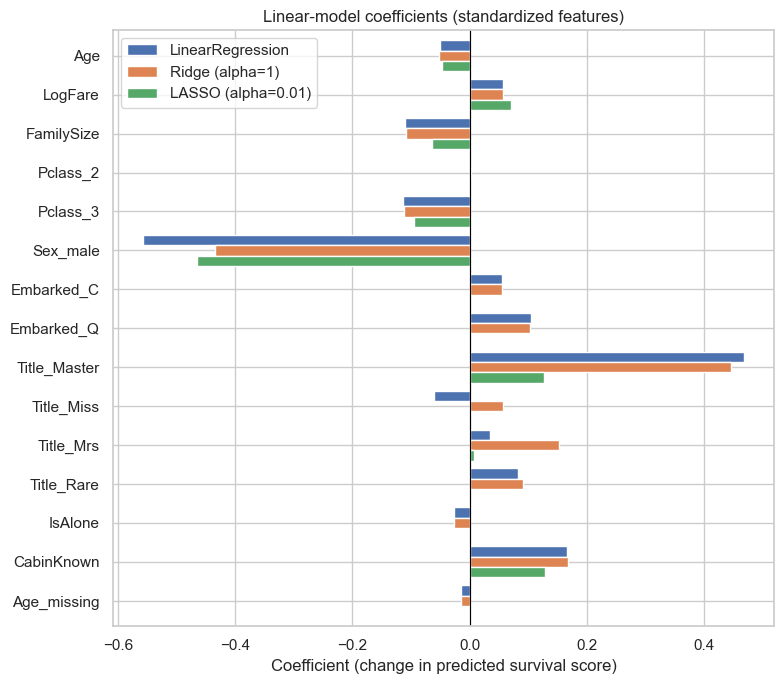

In [48]:
ax = coefficients.plot.barh(figsize=(8, 7), width=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.invert_yaxis()
ax.set_title("Linear-model coefficients (standardized features)")
ax.set_xlabel("Coefficient (change in predicted survival score)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

**Interpretation.** In all three models the sign pattern is consistent: being male lowers the survival score the most (−0.56 in the unpenalized fit), and being a `Master` (young boy) raises it (+0.47). Third class, larger families and older age lower it, while a known cabin raises it.

The penalties behave as expected. Ridge shrinks `Sex_male` from −0.56 to −0.44 and redistributes weight onto `Title_Mrs` (0.04 to 0.15) and `Title_Miss` (−0.06 to 0.06): this is the Sex/Title collinearity noted above, which makes individual coefficients of those groups hard to interpret on their own. LASSO at α = 0.01 sets 7 of 15 coefficients exactly to zero (`Pclass_2`, `Embarked_C`, `Embarked_Q`, `Title_Miss`, `Title_Rare`, `IsAlone`, `Age_missing`), keeping a sparse model built mainly on sex, class, fare, family size, age, cabin and the `Master` title. This is a strong shrinkage choice, so LASSO also shrinks the retained coefficients (for example `Title_Master` falls from 0.47 to 0.13).


In [49]:
test_scores = {name: model.predict(X_test_linear) for name, model in linear_models.items()}

pd.DataFrame(
    {
        name: {
            "min score": scores.min(),
            "max score": scores.max(),
            "share outside [0, 1]": ((scores < 0) | (scores > 1)).mean(),
        }
        for name, scores in test_scores.items()
    }
).T.round(3)

,min score,max score,"share outside [0, 1]"
LinearRegression,-0.488,1.141,0.050
Ridge (alpha=1),-0.475,1.139,0.050
LASSO (alpha=0.01),-0.127,1.041,0.022


**Interpretation.** The linear scores are not probabilities: on the test partition the unpenalized model produces scores from about −0.49 to 1.14, and roughly 5% of its scores lie outside [0, 1] (about 2% for LASSO). The 0.5 threshold still turns every score into a class label, but the scores should not be read as calibrated survival probabilities.


## 8.4 Collect predictions

Every model's class predictions and scores are stored in one structure so evaluation uses the same interface for all of them:

- **Naive Bayes:** class = `predict`; score = estimated P(survived) from `predict_proba`.
- **Linear models:** class = `score >= THRESHOLD`; score = the raw regression output.


In [50]:
model_outputs = {}

for alpha, model in nb_models.items():
    model_outputs[f"BernoulliNB (alpha={alpha:g})"] = {
        "y_pred_train": model.predict(X_train_nb),
        "y_pred_test": model.predict(X_test_nb),
        "y_score_test": model.predict_proba(X_test_nb)[:, 1],
    }

for name, model in linear_models.items():
    train_score = model.predict(X_train_linear)
    test_score = model.predict(X_test_linear)
    model_outputs[name] = {
        "y_pred_train": (train_score >= THRESHOLD).astype(int),
        "y_pred_test": (test_score >= THRESHOLD).astype(int),
        "y_score_test": test_score,
    }

assert all(len(o["y_pred_test"]) == len(y_test) and len(o["y_pred_train"]) == len(y_train) for o in model_outputs.values())
assert all(set(np.unique(o["y_pred_test"])) <= {0, 1} for o in model_outputs.values())

list(model_outputs)

['BernoulliNB (alpha=0)',
 'BernoulliNB (alpha=0.01)',
 'BernoulliNB (alpha=1)',
 'BernoulliNB (alpha=10)',
 'BernoulliNB (alpha=100)',
 'LinearRegression',
 'Ridge (alpha=1)',
 'LASSO (alpha=0.01)']

### Prediction sanity check

A coarse check that every model produces sensible, non-degenerate predictions before the full metric suite.


In [51]:
pd.DataFrame(
    {
        name: {
            "train accuracy": accuracy_score(y_train, outputs["y_pred_train"]),
            "test accuracy": accuracy_score(y_test, outputs["y_pred_test"]),
            "share predicted survived (test)": outputs["y_pred_test"].mean(),
        }
        for name, outputs in model_outputs.items()
    }
).T.round(3)

,train accuracy,test accuracy,share predicted survived (test)
BernoulliNB (alpha=0),0.782,0.732,0.464
BernoulliNB (alpha=0.01),0.782,0.732,0.464
BernoulliNB (alpha=1),0.782,0.732,0.464
BernoulliNB (alpha=10),0.782,0.726,0.447
BernoulliNB (alpha=100),0.777,0.771,0.302
LinearRegression,0.834,0.838,0.369
Ridge (alpha=1),0.833,0.838,0.358
LASSO (alpha=0.01),0.801,0.799,0.341


**Interpretation.** All eight models run, none collapses to a single class (the share predicted "survived" ranges well inside 0–1), and training and test accuracy are close, which does not indicate severe overfitting.

- Naive Bayes is unchanged for α ∈ {0, 0.01, 1} (identical accuracy), slightly different at α = 10 and different again at α = 100, consistent with the diagnostic above that smoothing only matters once it is strong relative to the counts. A higher accuracy at α = 100 would **not** justify choosing it: that would be tuning on the test partition.
- With α ≤ 1, Naive Bayes labels 46.4% of the test passengers as survivors, although only 38.5% actually survived, whereas the linear models label 34–37%.
- The linear models score higher than Naive Bayes on this split. A plausible reason is that Naive Bayes's independence assumption is violated by overlapping features (`Sex_male` with `Title_*`; `Pclass` with the fare bands and `CabinKnown`), which makes it count the same evidence repeatedly.
- LASSO at α = 0.01 is less accurate than Ridge and plain Linear Regression here, consistent with its stronger shrinkage.


# 9. Model Evaluation

All eight models are evaluated on the **same held-out test partition** (179 passengers whose labels no model saw during training). The positive class is **survived (1)**.

| Metric | What it answers |
|---|---|
| Accuracy | Share of all predictions that are correct |
| Confusion matrix | Where the errors are: false alarms vs. missed survivors |
| Precision, Recall, F1 | Of those predicted to survive, how many did (precision); of those who survived, how many were found (recall); their harmonic mean (F1) |
| ROC curve, AUC | Ranking quality across *all* thresholds, independent of the 0.5 cut-off |

Evaluation rules:

- **Nothing is selected or tuned from these results.** The test partition is used only to report.
- The majority-class baseline ("always predict died") is shown as a reference point.
- Because 179 rows is a small test set, accuracy is reported with an approximate 95% margin so that small differences are not over-interpreted.


## 9.1 Metrics for all models

In [52]:
def summarize_model(y_true, y_pred, y_score):
    accuracy = accuracy_score(y_true, y_pred)
    return {
        "accuracy": accuracy,
        "accuracy 95% half-width": 1.96 * np.sqrt(accuracy * (1 - accuracy) / len(y_true)),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_score),
    }


metrics_table = pd.DataFrame(
    {
        name: summarize_model(y_test, outputs["y_pred_test"], outputs["y_score_test"])
        for name, outputs in model_outputs.items()
    }
).T

majority_baseline = 1 - y_test.mean()
print(f"Majority-class baseline accuracy (always predict died): {majority_baseline:.3f}")

metrics_table.round(3)

Majority-class baseline accuracy (always predict died): 0.615


,accuracy,accuracy 95% half-width,precision,recall,f1,roc_auc
BernoulliNB (alpha=0),0.732,0.065,0.627,0.754,0.684,0.815
BernoulliNB (alpha=0.01),0.732,0.065,0.627,0.754,0.684,0.815
BernoulliNB (alpha=1),0.732,0.065,0.627,0.754,0.684,0.815
BernoulliNB (alpha=10),0.726,0.065,0.625,0.725,0.671,0.821
BernoulliNB (alpha=100),0.771,0.062,0.759,0.594,0.667,0.819
LinearRegression,0.838,0.054,0.803,0.768,0.785,0.868
Ridge (alpha=1),0.838,0.054,0.812,0.754,0.782,0.867
LASSO (alpha=0.01),0.799,0.059,0.770,0.681,0.723,0.849


In [53]:
for name in ["BernoulliNB (alpha=1)", "LinearRegression"]:
    print(f"=== {name} ===")
    print(classification_report(y_test, model_outputs[name]["y_pred_test"], target_names=["died", "survived"], digits=3))

=== BernoulliNB (alpha=1) ===
              precision    recall  f1-score   support

        died      0.823     0.718     0.767       110
    survived      0.627     0.754     0.684        69

    accuracy                          0.732       179
   macro avg      0.725     0.736     0.726       179
weighted avg      0.747     0.732     0.735       179

=== LinearRegression ===
              precision    recall  f1-score   support

        died      0.858     0.882     0.870       110
    survived      0.803     0.768     0.785        69

    accuracy                          0.838       179
   macro avg      0.831     0.825     0.828       179
weighted avg      0.837     0.838     0.837       179



**Interpretation.**

- **Every model beats the baseline** of 61.5% accuracy, so all of them learned real signal.
- **Linear models lead on accuracy and F1.** `LinearRegression` and `Ridge` both reach 0.838 accuracy (F1 0.785 and 0.782; AUC 0.868 and 0.867). `LASSO` is lower at 0.799 (F1 0.723, AUC 0.849), consistent with its stronger shrinkage.
- **Naive Bayes is weaker on accuracy**: 0.732 for α ≤ 1, with high recall (0.754) but low precision (0.627): it finds most survivors but raises many false alarms.
- **The gaps need cautious reading.** With 179 test passengers the 95% margin on accuracy is about ±5 to ±6.5 points. The 10.6-point gap between Naive Bayes (α ≤ 1) and Linear Regression exceeds either margin, although the intervals overlap slightly, so the evidence favors the linear models without being conclusive. The 4-point gap between LASSO and Ridge is within noise.
- **The ranking gap is smaller than the accuracy gap.** AUC is 0.815 for Naive Bayes versus 0.868 for Linear Regression (a difference of about 0.05, versus 0.11 in accuracy). Naive Bayes therefore ranks passengers reasonably well, but its 0.5 cut-off lands in a poor place; Section 9.4 shows that its probabilities are overconfident.


## 9.2 Confusion matrices

Heatmaps for Naive Bayes at every smoothing level and for the three linear models. Rows are the true class and columns the predicted class.

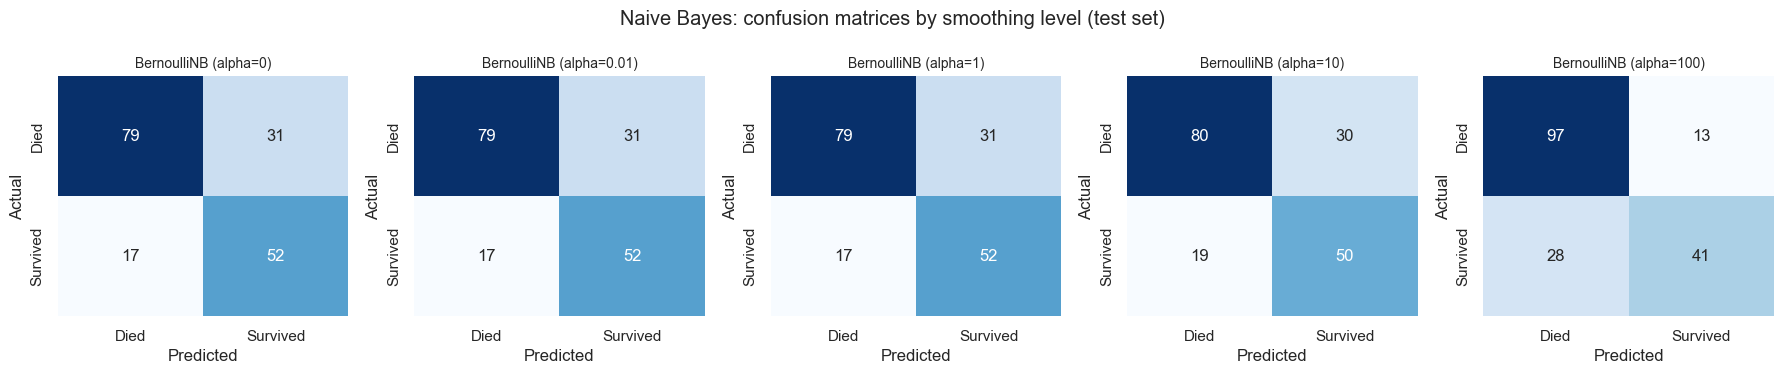

In [54]:
CLASS_LABELS = ["Died", "Survived"]


def plot_confusion_matrices(model_names, title):
    fig, axes = plt.subplots(1, len(model_names), figsize=(3.6 * len(model_names), 3.8))
    for ax, name in zip(np.atleast_1d(axes), model_names):
        matrix = confusion_matrix(y_test, model_outputs[name]["y_pred_test"], labels=[0, 1])
        sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS, ax=ax)
        ax.set_title(name, fontsize=10)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


nb_names = [name for name in model_outputs if name.startswith("BernoulliNB")]
linear_names = [name for name in model_outputs if not name.startswith("BernoulliNB")]

plot_confusion_matrices(nb_names, "Naive Bayes: confusion matrices by smoothing level (test set)")

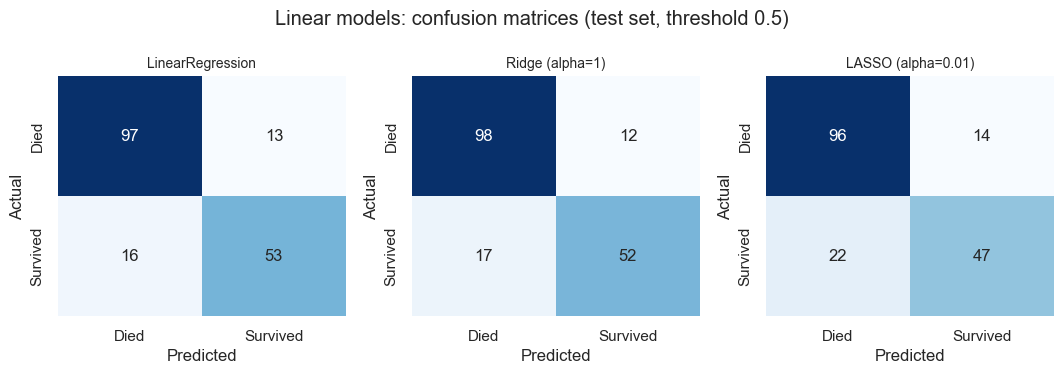

In [55]:
plot_confusion_matrices(linear_names, "Linear models: confusion matrices (test set, threshold 0.5)")

In [56]:
pd.DataFrame(
    {
        name: dict(zip(["TN", "FP", "FN", "TP"], confusion_matrix(y_test, outputs["y_pred_test"]).ravel()))
        for name, outputs in model_outputs.items()
    }
).T

,TN,FP,FN,TP
BernoulliNB (alpha=0),79,31,17,52
BernoulliNB (alpha=0.01),79,31,17,52
BernoulliNB (alpha=1),79,31,17,52
BernoulliNB (alpha=10),80,30,19,50
BernoulliNB (alpha=100),97,13,28,41
LinearRegression,97,13,16,53
Ridge (alpha=1),98,12,17,52
LASSO (alpha=0.01),96,14,22,47


**Interpretation.** The error profiles differ more than the accuracies suggest:

- **Naive Bayes (α ≤ 1)** makes 31 false alarms (FP) against 17 missed survivors (FN). It over-predicts survival (46.4% of test passengers labelled survivors versus 38.5% actual survivors).
- **Linear Regression** makes only 13 false alarms and 16 misses, so its advantage is almost entirely fewer false alarms; it finds about as many survivors (53 versus 52).
- **Heavy smoothing (α = 100)** removes the false alarms (13) but misses more survivors (28 FN, recall 0.59): smoothing shifted the model's operating point, not its ranking ability (AUC 0.819 versus 0.815).
- **LASSO** sits in between (14 FP, 22 FN), losing recall because it has zeroed informative small effects.

## 9.3 ROC curves and AUC

The ROC curve shows the trade-off between catching survivors (true-positive rate) and raising false alarms (false-positive rate) across **all** thresholds. For Naive Bayes the score is the predicted P(survived); for the linear models it is the raw regression output. AUC depends only on the ordering of scores, so the fact that linear scores are not probabilities does not affect it.

Naive Bayes with α = 0, 0.01 and 10 is omitted from the plot because its curve is visually indistinguishable from α = 1 (or, for α = 10, close to it); all AUC values are in the table above.

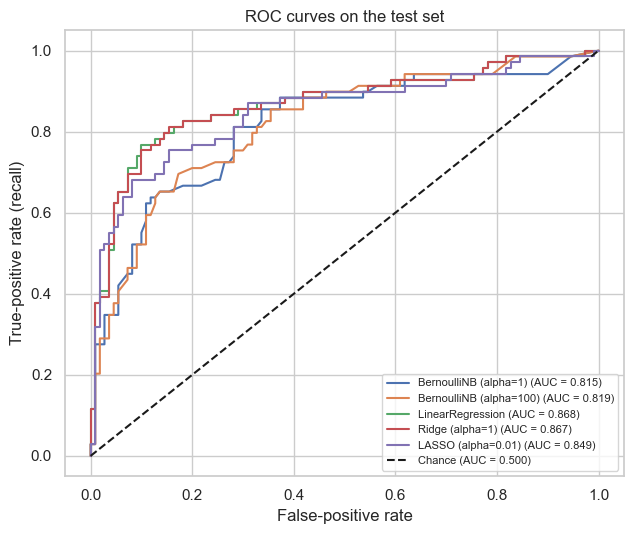

In [57]:
ROC_MODELS = [
    "BernoulliNB (alpha=1)",
    "BernoulliNB (alpha=100)",
    "LinearRegression",
    "Ridge (alpha=1)",
    "LASSO (alpha=0.01)",
]

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for name in ROC_MODELS:
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, model_outputs[name]["y_score_test"])
    ax.plot(false_positive_rate, true_positive_rate, label=f"{name} (AUC = {metrics_table.loc[name, 'roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", label="Chance (AUC = 0.500)")
ax.set_title("ROC curves on the test set")
ax.set_xlabel("False-positive rate")
ax.set_ylabel("True-positive rate (recall)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

**Interpretation.** All curves lie well above the chance diagonal. The three linear models are clearly ahead of Naive Bayes in the region of low false-positive rate, which is where a classifier avoids false alarms; at higher false-positive rates the curves converge. Ridge and Linear Regression are almost indistinguishable (AUC 0.867 vs. 0.868), and LASSO is slightly lower (0.849). The two Naive Bayes curves shown (α = 1 and α = 100) have nearly the same AUC (0.815 and 0.819), which confirms that smoothing changed where predictions fall relative to the 0.5 threshold far more than it changed how passengers are ranked.

## 9.4 Smoothing vs. no smoothing

Evidence comes from three views: the effect on the full-data models (a table), the effect on the predicted probabilities (a histogram), and a small-sample stress test.

**Reference for "no smoothing":** α = 0. Smoothing strengths compared: α = 0.01 (minimal), α = 1 (Laplace), α = 10 and 100 (heavy).


In [58]:
nb_outputs = {alpha: model_outputs[f"BernoulliNB (alpha={alpha:g})"] for alpha in NB_ALPHAS}
reference_pred = nb_outputs[0.0]["y_pred_test"]  # no smoothing
reference_score = nb_outputs[0.0]["y_score_test"]

pd.DataFrame(
    {
        f"alpha={alpha:g}": {
            "test accuracy": accuracy_score(y_test, outputs["y_pred_test"]),
            "predictions changed vs. no smoothing": int((outputs["y_pred_test"] != reference_pred).sum()),
            "max |change in P(survived)| vs. no smoothing": np.abs(outputs["y_score_test"] - reference_score).max(),
            "share of confident predictions (P < 0.05 or > 0.95)": (
                (outputs["y_score_test"] < 0.05) | (outputs["y_score_test"] > 0.95)
            ).mean(),
        }
        for alpha, outputs in nb_outputs.items()
    }
).T.round(3)

,test accuracy,predictions changed vs. no smoothing,max |change in P(survived)| vs. no smoothing,share of confident predictions (P < 0.05 or > 0.95)
alpha=0,0.732,0.0,0.000,0.626
alpha=0.01,0.732,0.0,0.000,0.626
alpha=1,0.732,0.0,0.039,0.620
alpha=10,0.726,3.0,0.136,0.592
alpha=100,0.771,29.0,0.456,0.497


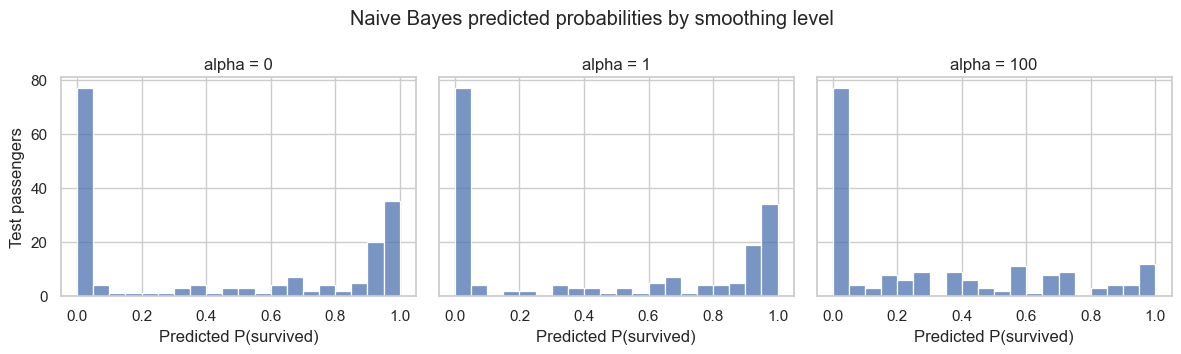

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, alpha in zip(axes, [0.0, 1.0, 100.0]):
    sns.histplot(nb_outputs[alpha]["y_score_test"], bins=20, binrange=(0, 1), ax=ax)
    ax.set_title(f"alpha = {alpha:g}")
    ax.set_xlabel("Predicted P(survived)")
axes[0].set_ylabel("Test passengers")
fig.suptitle("Naive Bayes predicted probabilities by smoothing level")
plt.tight_layout()
plt.show()

**Interpretation (full training data).**

- **Mild smoothing changes almost nothing.** α = 0.01 and α = 1 give exactly the same 179 test predictions as no smoothing, and the largest change in any predicted probability is about 0.04. This matches the training diagnostic above: with 712 training rows and dense binary features, every feature/class count is at least 3, so no probability estimate was ever zero.
- **Heavy smoothing changes the model's behaviour.** At α = 100 the probabilities are pulled toward the class prior: confident predictions fall from about 63% of the test set to about 50%, accuracy moves to 0.771, and the balance shifts from false alarms to missed survivors (Section 9.2).
- **Naive Bayes is overconfident even without heavy smoothing.** About 62% of its test predictions have P(survived) below 0.05 or above 0.95, although the model is right only 73% of the time. That is the independence assumption at work: overlapping features (for example `Sex_male` and `Title_*`) are counted as independent evidence, so the same evidence is multiplied in more than once.
- **A higher accuracy at α = 100 is not a reason to select it.** It reflects a different operating point on the same ranking (almost equal AUC), and choosing it from test accuracy would be tuning on the test partition.


### 9.4.1 Small-sample stress test

Smoothing exists to protect against feature values that never appear in a class in the training data. Our training set is large enough that this never happens, so the next experiment **reduces the training data** to show when smoothing matters. For each size, 100 random subsets of the training partition are drawn (fixed seed), a Naive Bayes model is fitted at three smoothing levels on the **same** subsets, and each is scored on the full test partition. Nothing is selected from this experiment; it is an illustration.

When an unsmoothed model has a zero probability for a feature value, the score of the affected class becomes exactly zero (negative infinity in log space). If both classes are affected, no information is left and the prediction degenerates.

In [60]:
STRESS_SIZES = [10, 20, 40, 80, 160, 320]
STRESS_REPEATS = 100
STRESS_ALPHAS = [0.0, 0.01, 1.0]

rng = np.random.default_rng(RANDOM_STATE)
stress_rows = []

# Unsmoothed models produce log(0); the resulting numpy warnings are expected and not informative here.
with np.errstate(all="ignore"):
    for size in STRESS_SIZES:
        accuracies = {alpha: [] for alpha in STRESS_ALPHAS}
        has_zero_probability = []
        for _ in range(STRESS_REPEATS):
            subset = rng.choice(len(X_train_nb), size=size, replace=False)
            y_subset = y_train.iloc[subset]
            if y_subset.nunique() < 2:
                continue
            for alpha in STRESS_ALPHAS:
                model = BernoulliNB(alpha=alpha, force_alpha=True, binarize=None).fit(X_train_nb.iloc[subset], y_subset)
                accuracies[alpha].append(accuracy_score(y_test, model.predict(X_test_nb)))
                if alpha == 0.0:
                    has_zero_probability.append(bool(np.isneginf(model.feature_log_prob_).any()))
        stress_rows.append(
            {
                "training rows": size,
                **{f"accuracy, alpha={alpha:g}": np.mean(values) for alpha, values in accuracies.items()},
                "share of subsets with zero-probability estimates (alpha=0)": np.mean(has_zero_probability),
            }
        )

stress_results = pd.DataFrame(stress_rows).set_index("training rows")
stress_results.round(3)

,"accuracy, alpha=0","accuracy, alpha=0.01","accuracy, alpha=1",share of subsets with zero-probability estimates (alpha=0)
training rows,,,,
10,0.615,0.659,0.698,1.00
20,0.615,0.693,0.723,1.00
40,0.602,0.723,0.734,1.00
80,0.535,0.741,0.740,0.93
160,0.538,0.746,0.743,0.64
320,0.686,0.738,0.737,0.15


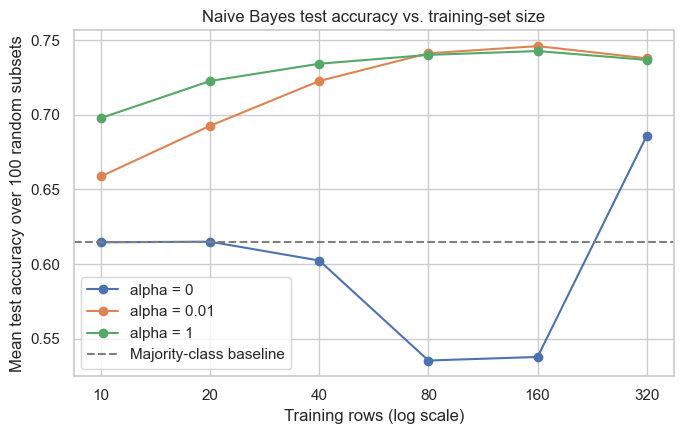

In [61]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for alpha in STRESS_ALPHAS:
    ax.plot(stress_results.index, stress_results[f"accuracy, alpha={alpha:g}"], marker="o", label=f"alpha = {alpha:g}")
ax.axhline(majority_baseline, color="gray", linestyle="--", label="Majority-class baseline")
ax.set_xscale("log")
ax.set_xticks(STRESS_SIZES)
ax.set_xticklabels(STRESS_SIZES)
ax.set_title("Naive Bayes test accuracy vs. training-set size")
ax.set_xlabel("Training rows (log scale)")
ax.set_ylabel("Mean test accuracy over 100 random subsets")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation (stress test).**

- **Without smoothing, small samples break the model.** Every random subset of 10–40 rows (and 93% of the 80-row subsets) contains at least one zero-probability estimate. Mean accuracy for α = 0 stays between 0.54 and 0.62 for subsets of 10–160 rows, at or **below the 61.5% majority baseline**: the model is then no better than a constant prediction. It recovers only partly at 320 rows (0.686), where 15% of subsets still contain a zero estimate.
- **Laplace smoothing prevents this.** With α = 1 the same subsets give 0.70 accuracy from just 10 training rows and about 0.73 from 40 rows.
- **α = 0.01 is a partial fix.** It removes the exact zeros, so it already recovers most of the accuracy (0.66 to 0.69 at 10–20 rows, approaching α = 1 from about 40 rows), but it trails α = 1 on the smallest samples because a probability of 0.01 is still extreme.
- **The effect disappears as data grows.** From about 80 rows on, α = 0.01 and α = 1 are equivalent, and the zero-probability share of unsmoothed models falls (64% at 160 rows, 15% at 320 rows). With the full 712 rows no zero estimate occurs, which is why the main results above show no difference between α = 0 and α = 1.

**Conclusion.** Smoothing is a safeguard whose value depends on data size. It was essential for small samples, irrelevant at mild strength with the full training set, and harmful to calibration/operating point when too strong (α = 100).


## 9.5 Summary of findings

| Question | Evidence | Answer |
|---|---|---|
| Which model family performed best? | Accuracy, F1, AUC | The linear models (`LinearRegression`, `Ridge`) — 0.838 accuracy, F1 ≈ 0.78, AUC ≈ 0.87 — ahead of Naive Bayes (0.732, F1 0.684, AUC 0.815); the gap is suggestive rather than conclusive given 179 test rows |
| Why is Naive Bayes weaker? | Confusion matrices, probability histogram | Too many false alarms and overconfident probabilities, consistent with violated independence between overlapping features |
| Did regularization help? | Metrics, coefficients | `Ridge` matches `LinearRegression`; `LASSO` at α = 0.01 gives a sparser model but loses recall and accuracy |
| Smoothing vs. no smoothing? | 9.4 tables and stress test | No effect on the full data for α ≤ 1; essential on small samples; heavy smoothing changes the operating point |
| Is accuracy alone enough? | Baseline, precision/recall, AUC | No: the baseline is 61.5%, and models with similar accuracy differ in precision/recall |

**Limitations:**

- A single 80/20 split with 179 test rows gives noisy estimates; cross-validation would give more stable estimates but was not used here.
- Linear Regression produces scores, not calibrated probabilities (5% fall outside [0, 1]).
- Naive Bayes's independence assumption is violated by overlapping `Sex`/`Title` and `Pclass`/fare/cabin features.
- No threshold other than 0.5 was explored for the linear models.
- Imputed ages affect `Age` and `AgeGroup`.
